In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [212]:
#Загружаем тренировочный датасет с изображениями цифр
train_data = pd.read_csv('data/train.csv')

In [213]:
#Датасет представляет из себя первую колонку - label цифры, все последующие колонки значение пикселя 28х28
train_data.head(2)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [214]:
#Формируем переменые размеров и перемешиваем данные
train_data = np.array(train_data)
m, n = train_data.shape
np.random.shuffle(train_data)

In [215]:
#Формируем тестовую выборку и нормазилизуем пиксели, чтобы они были распределены от 0 до 1
test_data = train_data[:1000].T
y_test = test_data[0]
X_test = test_data[1:n] / 255

In [216]:
#Формируем тренировочную выборку и нормазилизуем пиксели, чтобы они были распределены от 0 до 1
train = train_data[1000:m].T
y_train = train[0]
X_train = train[1:n] / 255

In [217]:
class SimpleNeuralNetwork:
    def init_params(self):
        '''Инициируем веса и смещения со сдвигом, чтобы значения не были равные нулю'''
        W1 = np.random.rand(10, 784) - 0.5
        b1 = np.random.rand(10, 1) - 0.5
        W2 = np.random.rand(10, 10) - 0.5
        b2 = np.random.rand(10, 1) - 0.5
        return W1, b1, W2, b2
    

    def relu(self,Z):
        '''Функция активации для скрытых слоев'''
        return np.maximum(Z, 0)
    
    def softmax(self,Z):
        '''Функция активации для выходного слоя'''
        return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)
    
    def relu_deriv(self, Z):
        '''Производная ReLu'''
        return Z > 0
    
    def forward_prop(self,W1, b1, W2, b2, X):
        '''Прямое распространение'''
        Z1 = W1.dot(X) + b1
        A1 = self.relu(Z1)
        Z2 = W2.dot(A1) + b2
        A2 = self.softmax(Z2)
        return Z1, A1, Z2, A2
    
    def one_hot(self, Y):
        '''Кодирование лейблов цифр'''
        one_hot_y = np.zeros((Y.size, Y.max() + 1))
        one_hot_y[np.arange(Y.size), Y] = 1
        return one_hot_y.T
    
    def backward_prop(self, Z1, A1, Z2, A2, W1, W2, X, Y):
        '''Обратное распространение ошибки'''
        m = X.shape[1]
        one_hot_y = self.one_hot(Y)
        dZ2 = A2 - one_hot_y
        dW2 = 1 / m *dZ2.dot(A1.T)
        db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
        dZ1 = W2.T.dot(dZ2) * self.relu_deriv(Z1)
        dW1 = 1 / m * dZ1.dot(X.T)
        db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
        return dW1, db1, dW2, db2

    def update_params(self, W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
        '''Обновляем веса и коэффициент смещения'''
        W1 = W1 - alpha * dW1
        b1 = b1 - alpha * db1
        W2 = W2 - alpha * dW2
        b2 = b2 - alpha * db2
        return W1, b1, W2, b2

    def get_predictions(self, A2):
        '''Возвращаем максимальную предсказанную вероятность цифры'''
        return np.argmax(A2,0)
    
    def get_accuracy(self, predictions, Y):
        '''Расчет метрики качества'''
        return np.sum(predictions == Y) / Y.size

In [218]:

nn = SimpleNeuralNetwork()

def gradient_descent(X, Y, alpha, iterations):
    '''Запуск обучения нейросети'''
    W1, b1, W2, b2 = nn.init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = nn.forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = nn.backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = nn.update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print(f"Iteration: {i}")
            predictions = nn.get_predictions(A2)
            print(nn.get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [219]:
W1, b1, W2, b2 = gradient_descent(X_train, y_train, 0.10, 500)

Iteration: 0
0.048439024390243904
Iteration: 10
0.1683658536585366
Iteration: 20
0.2505121951219512
Iteration: 30
0.3362926829268293
Iteration: 40
0.4036585365853659
Iteration: 50
0.462219512195122
Iteration: 60
0.5318780487804878
Iteration: 70
0.5917560975609756
Iteration: 80
0.6307073170731707
Iteration: 90
0.6610975609756098
Iteration: 100
0.6828536585365854
Iteration: 110
0.7010243902439024
Iteration: 120
0.7162682926829268
Iteration: 130
0.7291463414634146
Iteration: 140
0.7406585365853658
Iteration: 150
0.7493414634146341
Iteration: 160
0.7580487804878049
Iteration: 170
0.7660731707317073
Iteration: 180
0.7731219512195122
Iteration: 190
0.7795365853658537
Iteration: 200
0.7854634146341464
Iteration: 210
0.7903414634146342
Iteration: 220
0.7947560975609756
Iteration: 230
0.7995121951219513
Iteration: 240
0.8035609756097561
Iteration: 250
0.8076341463414635
Iteration: 260
0.8109756097560976
Iteration: 270
0.8141463414634146
Iteration: 280
0.8172682926829268
Iteration: 290
0.8204634

Качество предсказаний обученной модели = 85%. Весьма неплохо для однослойной модели

In [225]:
def make_predictions(X, W1, b1, W2, b2):
    '''Предсказание на тестовой выборке'''
    _, _, _, A2 = nn.forward_prop(W1, b1, W2, b2, X)
    predictions = nn.get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_test[:, index, None]
    prediction = make_predictions(X_test[:, index, None], W1, b1, W2, b2)
    label = y_test[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

In [226]:
dev_predictions = make_predictions(X_test, W1, b1, W2, b2)
nn.get_accuracy(dev_predictions, y_test)

np.float64(0.87)

In [227]:
mistake_indices = np.where(dev_predictions != y_test)[0]

Prediction:  [3]
Label:  8


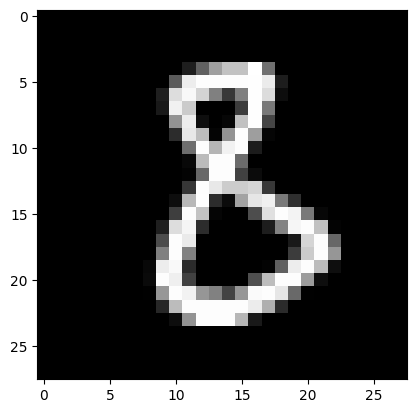

Prediction:  [0]
Label:  3


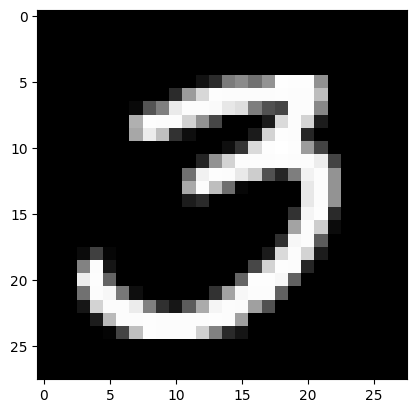

Prediction:  [9]
Label:  7


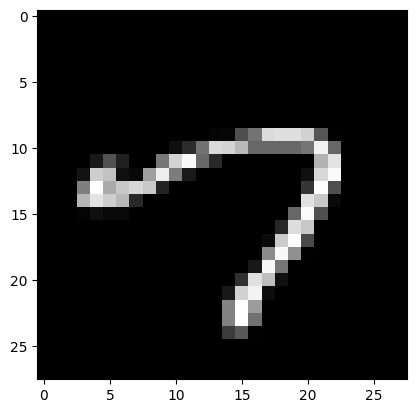

Prediction:  [9]
Label:  7


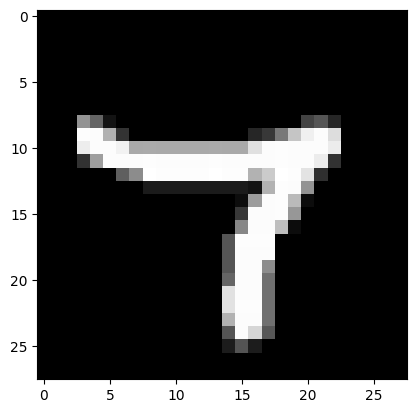

Prediction:  [6]
Label:  0


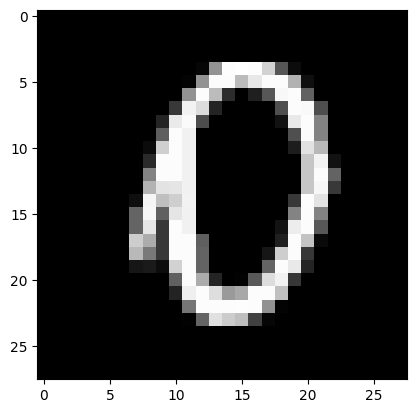

Prediction:  [5]
Label:  3


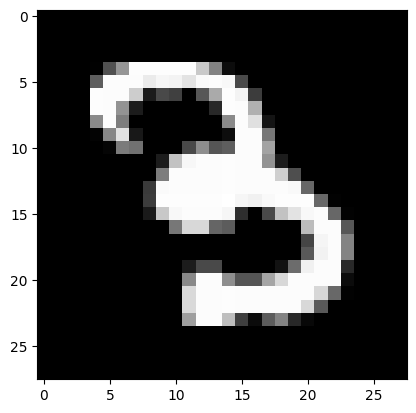

Prediction:  [5]
Label:  6


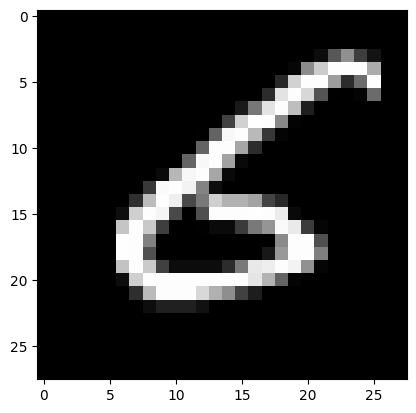

Prediction:  [9]
Label:  4


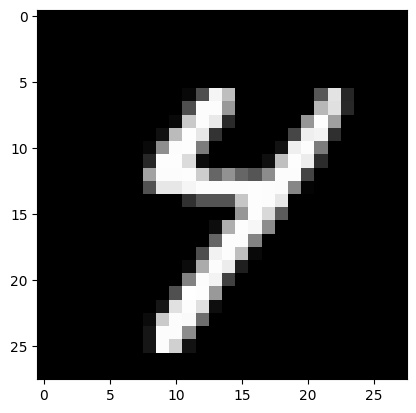

Prediction:  [9]
Label:  8


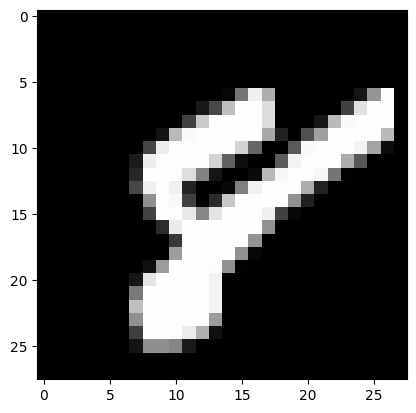

Prediction:  [9]
Label:  3


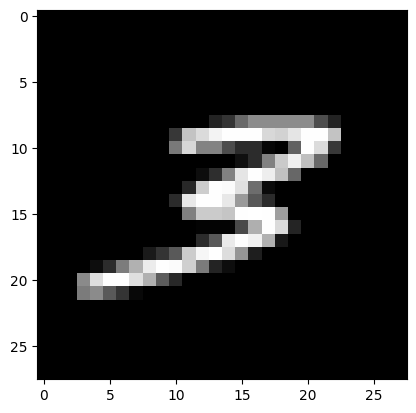

In [231]:
for idx in mistake_indices[:10]:
    test_prediction(idx, W1, b1, W2, b2)